<a href="https://colab.research.google.com/github/germanoisabela/DataScience/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    QuantileTransformer,
    PowerTransformer,
    Normalizer
)

from sklearn.decomposition import PCA
from sklearn.utils import resample

In [3]:
dados = pd.read_csv('diabetes.csv')

display(dados.sample(5))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
708,9,164,78,0,0,32.8,0.148,45,1
36,11,138,76,0,0,33.2,0.420,35,0
686,3,130,64,0,0,23.1,0.314,22,0
382,1,109,60,8,182,25.4,0.947,21,0
177,0,129,110,46,130,67.1,0.319,26,1


In [4]:
print("todos os dados sao relevantes")

todos os dados sao relevantes


In [16]:
import pandas as pd
import numpy as np


df = pd.read_csv('diabetes.csv')


cols_inconsistentes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']


df[cols_inconsistentes] = df[cols_inconsistentes].replace(0, np.nan)


print("Valores ausentes/inconsistentes por coluna:")
print(df.isnull().sum())


for col in cols_inconsistentes:
    df[col] = df[col].fillna(df[col].median())

print("\nValores ausentes/inconsistentes por coluna após tratamento:")
print(df.isnull().sum())

Valores ausentes/inconsistentes por coluna:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Valores ausentes/inconsistentes por coluna após tratamento:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dados após tratamento de ausentes: OK


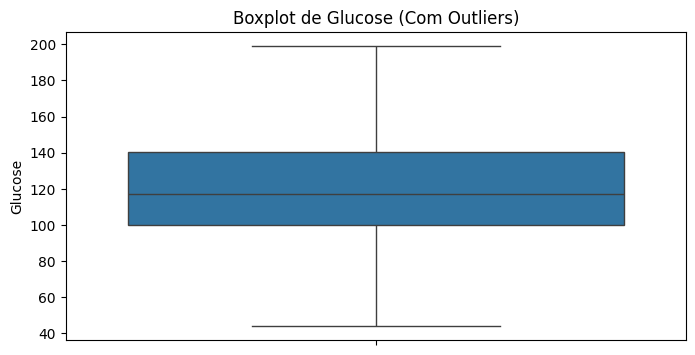

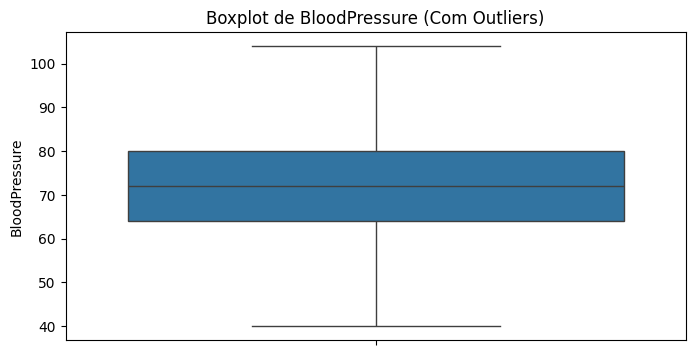

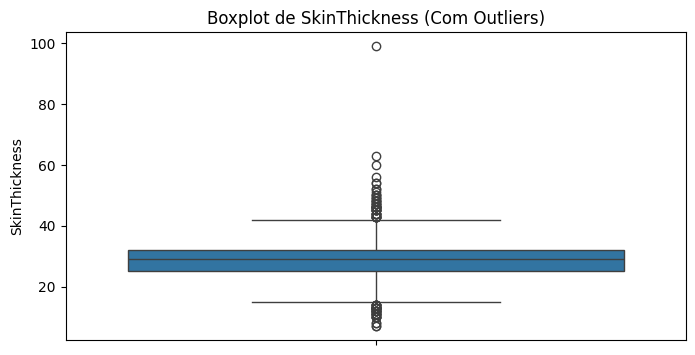

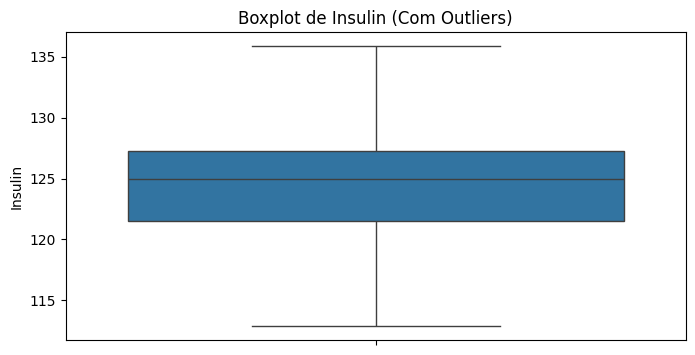

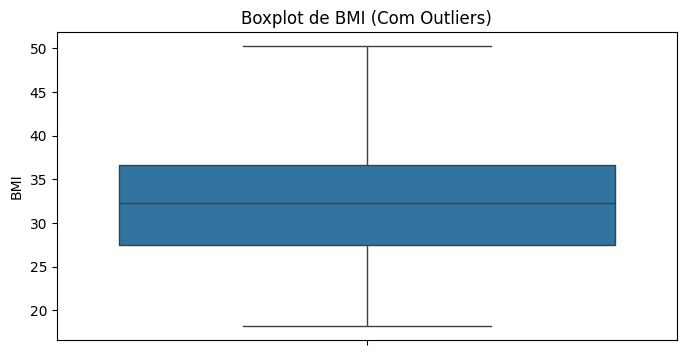

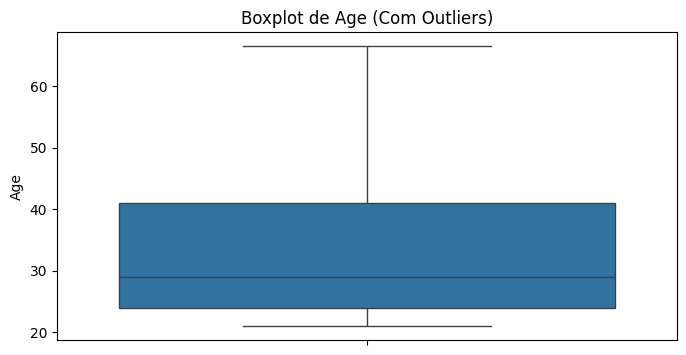

Outliers tratados via técnica de Capping (limitação aos quartis).


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


for col in cols_inconsistentes:
  plt.figure(figsize=(8,4))
  sns.boxplot(y=df[col])
  plt.title(f"Boxplot de {col} (Com Outliers)")
  plt.show()


def tratar_outliers(dados, coluna):
    Q1 = dados[coluna].quantile(0.25)
    Q3 = dados[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR


    dados[coluna] = np.where(dados[coluna] > limite_superior, limite_superior,
                    np.where(dados[coluna] < limite_inferior, limite_inferior, dados[coluna]))
    return dados


for col in ['Insulin', 'BMI', 'BloodPressure', 'DiabetesPedigreeFunction', 'Age']:
    df = tratar_outliers(df, col)

print("Outliers tratados via técnica de Capping (limitação aos quartis).")

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd


X = df.drop('Outcome', axis=1)


min_max_scaler = MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X)
df_minmax = pd.DataFrame(X_minmax, columns=X.columns)


std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)
df_std = pd.DataFrame(X_std, columns=X.columns)

display(df_minmax.sample(5))
print("\n\n")
display(df_std.sample(5))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
725,0.235294,0.438710,0.59375,0.358696,0.527174,0.661466,0.140820,0.373626
406,0.235294,0.458065,0.50000,0.239130,0.527174,0.333853,0.265597,0.549451
609,0.058824,0.432258,0.34375,0.065217,1.000000,0.180967,0.053476,0.043956
278,0.294118,0.451613,0.53125,0.239130,0.527174,0.209048,0.593583,0.791209
597,0.058824,0.290323,0.00000,0.130435,0.000000,0.299532,0.428699,0.000000


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
628,0.342981,0.208549,0.653744,-0.012301,0.039062,0.331172,-1.103373,1.015429
223,0.936914,0.668796,-1.057196,0.442995,1.414175,-0.539290,0.799151,2.392267
330,1.233880,-0.120198,-0.030632,-1.150541,0.039062,-1.394744,2.596563,1.101481
606,-0.844885,1.950912,0.482650,1.467410,1.414175,1.141602,2.596563,-0.963775
454,-0.547919,-0.711944,-1.570478,-0.126125,-1.494110,0.811427,0.136946,-0.791671
